<a href="https://colab.research.google.com/github/AnhThu150407/BTVN-AI-01/blob/main/BTVN_AI_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
â

# Chào mừng bạn đến với Colab!

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.2 MB/s eta 0:00:00
Giá dự đoán: 8.122222222222222
Điểm thưởng dự đoán: 8.643589743589743


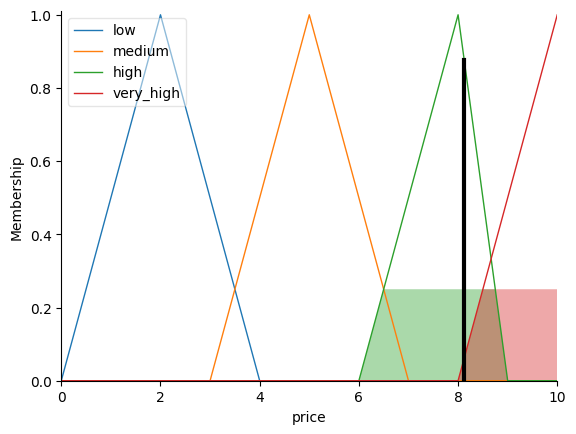

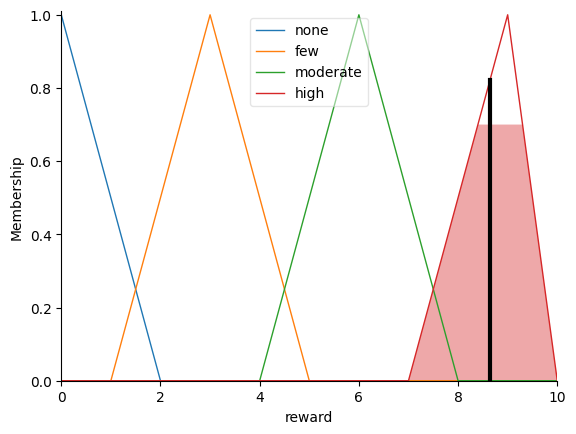

In [ ]:

!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')   # km
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')    # %
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')      # %
weather = ctrl.Antecedent(np.arange(0, 3, 1), 'weather')      # 0 tốt, 1 trung bình, 2 xấu
rating = ctrl.Antecedent(np.arange(1, 6, 0.1), 'rating')      # 1-5 sao
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality') # %

price = ctrl.Consequent(np.arange(0, 11, 1), 'price')         # mức giá 0-10
reward = ctrl.Consequent(np.arange(0, 11, 1), 'reward')       # điểm thưởng 0-10


distance['short'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['medium'] = fuzz.trimf(distance.universe, [2, 8, 15])
distance['long'] = fuzz.trimf(distance.universe, [6, 20, 35])
distance['very_long'] = fuzz.trimf(distance.universe, [15, 50, 50])

traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 50, 70])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

demand['low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzz.trimf(demand.universe, [20, 50, 70])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])

weather['good'] = fuzz.trimf(weather.universe, [0, 0, 0])
weather['moderate'] = fuzz.trimf(weather.universe, [1, 1, 1])
weather['bad'] = fuzz.trimf(weather.universe, [2, 2, 2])

rating['poor'] = fuzz.trimf(rating.universe, [1, 1.5, 2.5])
rating['average'] = fuzz.trimf(rating.universe, [2.6, 3.5, 4.0])
rating['good'] = fuzz.trimf(rating.universe, [3.5, 4.5, 5.0])

punctuality['late'] = fuzz.trimf(punctuality.universe, [0, 20, 50])
punctuality['on_time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzz.trimf(punctuality.universe, [70, 90, 100])

price['low'] = fuzz.trimf(price.universe, [0, 2, 4])
price['medium'] = fuzz.trimf(price.universe, [3, 5, 7])
price['high'] = fuzz.trimf(price.universe, [6, 8, 9])
price['very_high'] = fuzz.trimf(price.universe, [8, 10, 10])

reward['none'] = fuzz.trimf(reward.universe, [0, 0, 2])
reward['few'] = fuzz.trimf(reward.universe, [1, 3, 5])
reward['moderate'] = fuzz.trimf(reward.universe, [4, 6, 8])
reward['high'] = fuzz.trimf(reward.universe, [7, 9, 10])

rules_price = [
    ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low']),
    ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high']),
    ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium']),
    ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['low'] & demand['high'], price['high']),
    ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high']),
    ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium']),
]

rules_reward = [
    ctrl.Rule(rating['good'] & punctuality['early'], reward['high']),
    ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high']),
    ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few']),
    ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate']),
    ctrl.Rule(rating['good'] & punctuality['early'], reward['high']),
    ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high']),
    ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few']),
    ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate']),
]


pricing_ctrl = ctrl.ControlSystem(rules_price + rules_reward)
pricing = ctrl.ControlSystemSimulation(pricing_ctrl)

pricing.input['distance'] = 12
pricing.input['traffic'] = 70
pricing.input['demand'] = 80
pricing.input['weather'] = 2
pricing.input['rating'] = 4.2
pricing.input['punctuality'] = 85

pricing.compute()

print("Giá dự đoán:", pricing.output['price'])
print("Điểm thưởng dự đoán:", pricing.output['reward'])

price.view(sim=pricing)
reward.view(sim=pricing)


Mức giảm giá dự đoán (%): 60.000000000000014


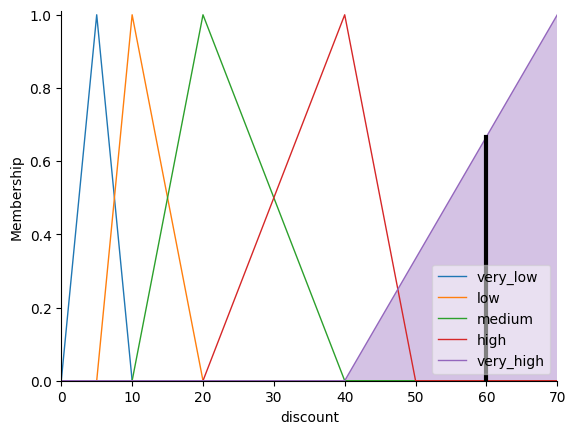

In [ ]:

!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

store_rating = ctrl.Antecedent(np.arange(0, 6, 0.1), 'store_rating')   # 1-5 sao
sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_volume')   # %
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin') # %
seasonal_event = ctrl.Antecedent(np.arange(0, 3, 1), 'seasonal_event') # 0 none, 1 moderate, 2 high
competitor_discount = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_discount') # %

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount') # % giảm giá

store_rating['low'] = fuzz.trimf(store_rating.universe, [0, 1.5, 4.0])
store_rating['medium'] = fuzz.trimf(store_rating.universe, [4.0, 4.3, 4.5])
store_rating['high'] = fuzz.trimf(store_rating.universe, [4.5, 5.0, 5.0])

sales_volume['low'] = fuzz.trimf(sales_volume.universe, [0, 20, 40])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe, [30, 50, 70])
sales_volume['high'] = fuzz.trimf(sales_volume.universe, [60, 80, 100])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 20, 40])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [30, 50, 70])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [60, 80, 100])

seasonal_event['none'] = fuzz.trimf(seasonal_event.universe, [0, 0, 0])
seasonal_event['moderate'] = fuzz.trimf(seasonal_event.universe, [1, 1, 1])
seasonal_event['high'] = fuzz.trimf(seasonal_event.universe, [2, 2, 2])

competitor_discount['low'] = fuzz.trimf(competitor_discount.universe, [0, 20, 40])
competitor_discount['medium'] = fuzz.trimf(competitor_discount.universe, [30, 50, 70])
competitor_discount['high'] = fuzz.trimf(competitor_discount.universe, [60, 80, 100])

discount['very_low'] = fuzz.trimf(discount.universe, [0, 5, 10])
discount['low'] = fuzz.trimf(discount.universe, [5, 10, 20])
discount['medium'] = fuzz.trimf(discount.universe, [10, 20, 40])
discount['high'] = fuzz.trimf(discount.universe, [20, 40, 50])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 70, 70])

rules = [
    ctrl.Rule(store_rating['high'] & sales_volume['high'] & profit_margin['high'], discount['very_low']),
    ctrl.Rule(store_rating['low'] & sales_volume['low'] & profit_margin['high'], discount['high']),
    ctrl.Rule(seasonal_event['high'] & competitor_discount['high'], discount['very_high']),
    ctrl.Rule(store_rating['medium'] & sales_volume['medium'] & profit_margin['medium'], discount['medium']),
    ctrl.Rule(competitor_discount['low'] & profit_margin['low'] & sales_volume['high'], discount['very_low']),
    ctrl.Rule(store_rating['low'] & seasonal_event['none'], discount['medium']),
    ctrl.Rule(sales_volume['low'] & profit_margin['low'], discount['very_high']),
]

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['store_rating'] = 4.3
discount_sim.input['sales_volume'] = 50
discount_sim.input['profit_margin'] = 20
discount_sim.input['seasonal_event'] = 2
discount_sim.input['competitor_discount'] = 80

discount_sim.compute()

print("Mức giảm giá dự đoán (%):", discount_sim.output['discount'])

discount.view(sim=discount_sim)


Mức giảm giá dự đoán (%): 23.88888888888889


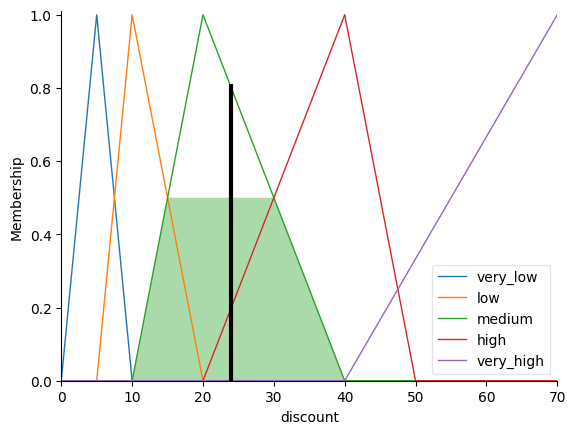

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

product_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'product_demand')
competitor_pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_pressure')
store_reputation = ctrl.Antecedent(np.arange(0, 6, 0.1), 'store_reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_demand = ctrl.Antecedent(np.arange(0, 3, 1), 'seasonal_demand')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount') # %

product_demand['low'] = fuzz.trimf(product_demand.universe, [0, 20, 40])
product_demand['medium'] = fuzz.trimf(product_demand.universe, [30, 50, 70])
product_demand['high'] = fuzz.trimf(product_demand.universe, [60, 80, 100])

competitor_pressure['low'] = fuzz.trimf(competitor_pressure.universe, [0, 20, 40])
competitor_pressure['medium'] = fuzz.trimf(competitor_pressure.universe, [30, 50, 70])
competitor_pressure['high'] = fuzz.trimf(competitor_pressure.universe, [60, 80, 100])

store_reputation['low'] = fuzz.trimf(store_reputation.universe, [0, 2.5, 4.0])
store_reputation['medium'] = fuzz.trimf(store_reputation.universe, [4.0, 4.3, 4.5])
store_reputation['high'] = fuzz.trimf(store_reputation.universe, [4.5, 5.0, 5.0])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 20, 40])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [30, 50, 70])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [60, 80, 100])

seasonal_demand['none'] = fuzz.trimf(seasonal_demand.universe, [0, 0, 0])
seasonal_demand['moderate'] = fuzz.trimf(seasonal_demand.universe, [1, 1, 1])
seasonal_demand['high'] = fuzz.trimf(seasonal_demand.universe, [2, 2, 2])

discount['very_low'] = fuzz.trimf(discount.universe, [0, 5, 10])
discount['low'] = fuzz.trimf(discount.universe, [5, 10, 20])
discount['medium'] = fuzz.trimf(discount.universe, [10, 20, 40])
discount['high'] = fuzz.trimf(discount.universe, [20, 40, 50])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 70, 70])


rules = [
    ctrl.Rule(product_demand['high'] & competitor_pressure['low'] & profit_margin['low'], discount['very_low']),
    ctrl.Rule(product_demand['low'] & competitor_pressure['high'] & profit_margin['high'], discount['high']),
    ctrl.Rule(store_reputation['high'] & profit_margin['medium'] & seasonal_demand['high'], discount['medium']),
    ctrl.Rule(competitor_pressure['high'] & seasonal_demand['high'] & profit_margin['high'], discount['very_high']),
    ctrl.Rule(store_reputation['low'] & product_demand['medium'] & profit_margin['low'], discount['medium']),
    ctrl.Rule(product_demand['high'] & seasonal_demand['none'] & competitor_pressure['low'], discount['very_low']),
    ctrl.Rule(profit_margin['high'] & competitor_pressure['medium'] & seasonal_demand['moderate'], discount['medium']),
]

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)


discount_sim.input['product_demand'] = 80
discount_sim.input['competitor_pressure'] = 50
discount_sim.input['store_reputation'] = 4.2
discount_sim.input['profit_margin'] = 70
discount_sim.input['seasonal_demand'] = 1

discount_sim.compute()

print("Mức giảm giá dự đoán (%):", discount_sim.output['discount'])


discount.view(sim=discount_sim)

=== KẾT QUẢ ===
Số đơn nên kết hợp (0-10): 8.142857142857142
Mức độ ưu tiên (0-10): 5.0
=> Nên kết hợp NHIỀU đơn (~5 đơn)
=> Ưu tiên TRUNG BÌNH


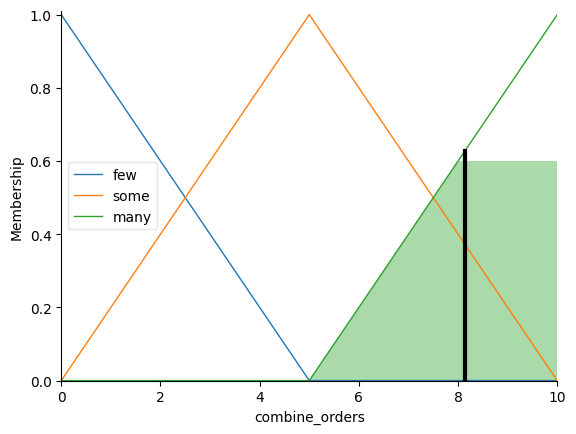

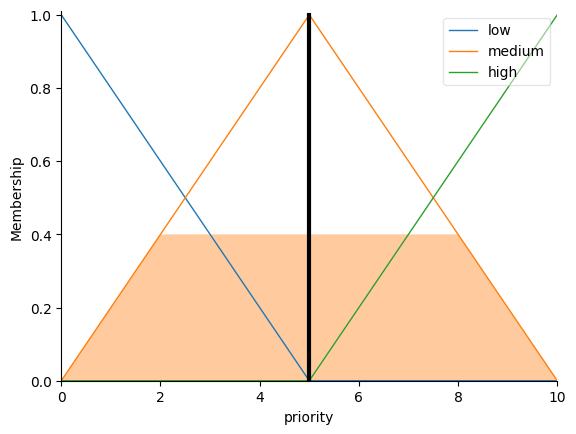

In [11]:

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

order_density = ctrl.Antecedent(np.arange(0, 11, 1), 'order_density')
urgency = ctrl.Antecedent(np.arange(0, 11, 1), 'urgency')
driver_load = ctrl.Antecedent(np.arange(0, 11, 1), 'driver_load')
traffic = ctrl.Antecedent(np.arange(0, 11, 1), 'traffic')
profit = ctrl.Antecedent(np.arange(0, 11, 1), 'profit')

combine_orders = ctrl.Consequent(np.arange(0, 11, 1), 'combine_orders')
priority = ctrl.Consequent(np.arange(0, 11, 1), 'priority')


for var in [order_density, urgency, driver_load, traffic, profit]:
    var['low'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['medium'] = fuzz.trimf(var.universe, [0, 5, 10])
    var['high'] = fuzz.trimf(var.universe, [5, 10, 10])

combine_orders['few'] = fuzz.trimf(combine_orders.universe, [0, 0, 5])
combine_orders['some'] = fuzz.trimf(combine_orders.universe, [0, 5, 10])
combine_orders['many'] = fuzz.trimf(combine_orders.universe, [5, 10, 10])

priority['low'] = fuzz.trimf(priority.universe, [0, 0, 5])
priority['medium'] = fuzz.trimf(priority.universe, [0, 5, 10])
priority['high'] = fuzz.trimf(priority.universe, [5, 10, 10])


rules = [

    ctrl.Rule(order_density['high'] & driver_load['low'] & traffic['low'],
              combine_orders['many']),

    ctrl.Rule(order_density['medium'] & traffic['high'] & urgency['medium'],
              combine_orders['some']),

    ctrl.Rule(driver_load['high'] & order_density['high'] & profit['medium'],
              combine_orders['some']),

    ctrl.Rule(order_density['low'] & urgency['high'] & traffic['medium'],
              combine_orders['some']),

    ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'],
              combine_orders['some']),

    ctrl.Rule(urgency['high'] & profit['high'],
              priority['high']),

    ctrl.Rule(urgency['medium'] & traffic['medium'],
              priority['medium']),

    ctrl.Rule(urgency['low'] & order_density['high'] & profit['low'],
              priority['low'])
]


system = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(system)


simulation.input['order_density'] = 8
simulation.input['urgency'] = 5
simulation.input['driver_load'] = 2
simulation.input['traffic'] = 2
simulation.input['profit'] = 5



simulation.compute()


print("=== KẾT QUẢ ===")
print("Số đơn nên kết hợp (0-10):", simulation.output['combine_orders'])
print("Mức độ ưu tiên (0-10):", simulation.output['priority'])

if simulation.output['combine_orders'] > 6:
    print("=> Nên kết hợp NHIỀU đơn (~5 đơn)")
elif simulation.output['combine_orders'] > 3:
    print("=> Nên kết hợp MỘT SỐ đơn")
else:
    print("=> Chỉ nên kết hợp ÍT đơn")

if simulation.output['priority'] > 6:
    print("=> Ưu tiên CAO")
elif simulation.output['priority'] > 3:
    print("=> Ưu tiên TRUNG BÌNH")
else:
    print("=> Ưu tiên THẤP")


combine_orders.view(sim=simulation)
priority.view(sim=simulation)
